In [82]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Зашумить изображение при помощи шума гаусса, постоянного шума

In [83]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

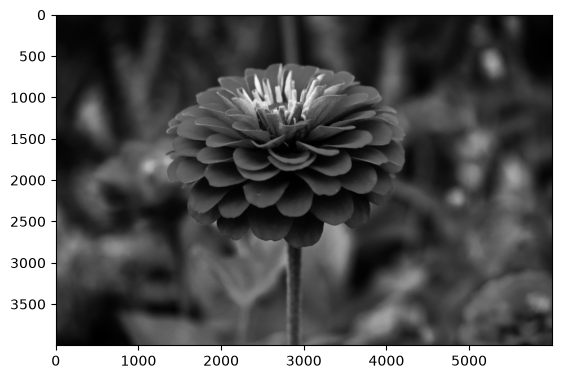

In [84]:
plt.imshow(image_gray, cmap="gray")

In [85]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,   0, 131, ...,   0,   0,   0],
       [  0,  56,   0, ...,   0,   0,  65],
       [ 24,   0,  49, ...,  40,   0,  91],
       ...,
       [  0,   0,  31, ..., 108,   8,  77],
       [  0,   0,  72, ...,   0,  94,  81],
       [103,   0,   0, ..., 149,  47,   0]],
      shape=(4000, 6000), dtype=uint8)

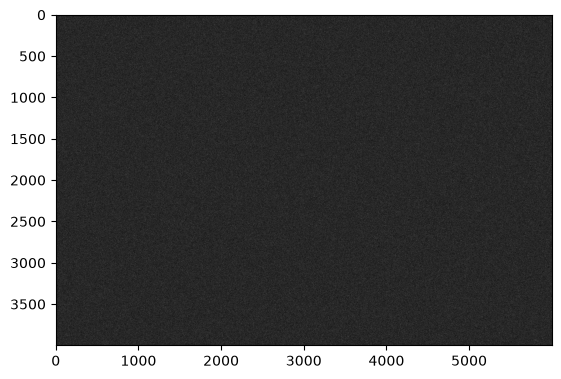

In [86]:
plt.imshow(noise_gauss, cmap="gray")

In [87]:
image_noise_gauss = cv2.add(image_gray, noise_gauss)

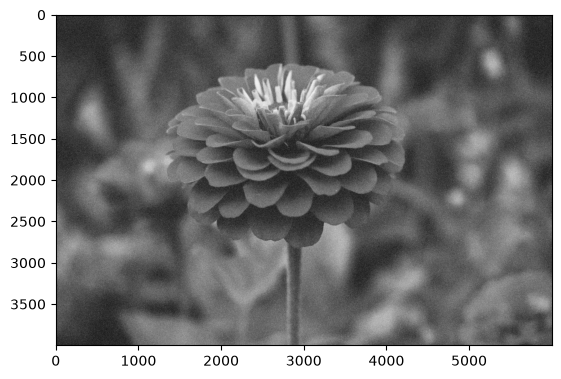

In [88]:
plt.imshow(image_noise_gauss, cmap="gray")

In [89]:
# Salt and pepper
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [90]:
bg_image = np.ones(image_gray.shape, np.uint8) * 128

In [91]:
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

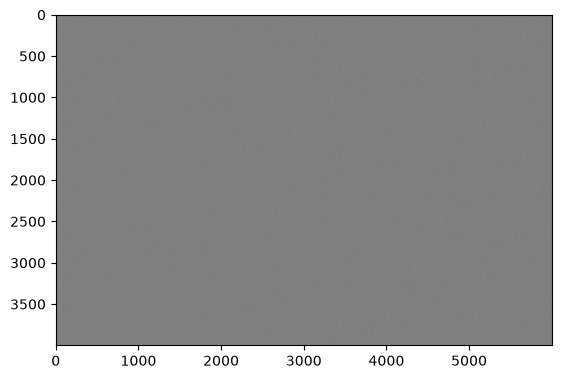

In [92]:
plt.imshow(bg_image, cmap="gray")

In [93]:
import copy
image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

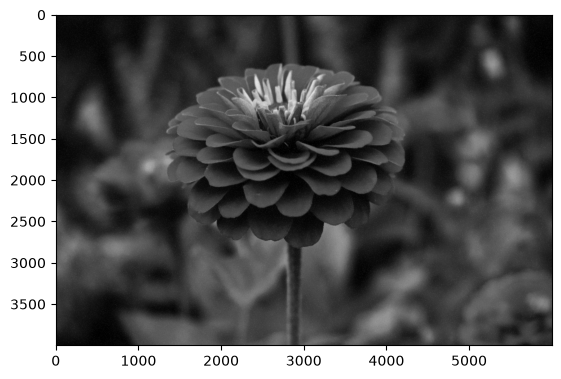

In [94]:
plt.imshow(image_sp, cmap="gray")

# 2. Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

In [95]:
from skimage.metrics import structural_similarity, mean_squared_error
def photo_comparison(image_src, image):
    (ssim, diff) = structural_similarity(image_src, image, full=True)
    mse = mean_squared_error(image_src, image)
    print(f"SSIM: {ssim} MSE: {mse}")

In [96]:
photo_comparison(image_gray, image_noise_gauss)
photo_comparison(image_gray, image_sp)
photo_comparison(image_noise_gauss, image_sp)

SSIM: 0.02592051904270341 MSE: 4498.618047
SSIM: 0.5481787702597674 MSE: 447.43659245833334
SSIM: 0.023173637320959246 MSE: 4833.3745077916665


In [103]:
image_gauss_median_3 = cv2.medianBlur(image_noise_gauss, 3)
image_gauss_median_5 = cv2.medianBlur(image_noise_gauss, 5)
image_gauss_nlm_10 = cv2.fastNlMeansDenoising(image_noise_gauss, h=10)
image_gauss_nlm_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)
image_gauss_bilat_1 = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
image_gauss_bilat_2 = cv2.bilateralFilter(image_noise_gauss, 5, 50, 50)

In [104]:
photo_comparison(image_gray, image_gauss_median_3)
photo_comparison(image_gray, image_gauss_median_5)
photo_comparison(image_gray, image_gauss_nlm_10)
photo_comparison(image_gray, image_gauss_nlm_20)
photo_comparison(image_gray, image_gauss_bilat_1)
photo_comparison(image_gray, image_gauss_bilat_2)


SSIM: 0.1540530321755048 MSE: 842.1674387916667
SSIM: 0.3663548929162905 MSE: 332.1539155
SSIM: 0.026118314245267414 MSE: 4498.480609458334
SSIM: 0.02895845056157844 MSE: 4486.334567041667
SSIM: 0.10453413130204899 MSE: 1786.2046826666667
SSIM: 0.0427034001650689 MSE: 3048.534290416667


In [105]:
image_sp_median_3 = cv2.medianBlur(image_sp, 3)
image_sp_median_5 = cv2.medianBlur(image_sp, 5)
image_sp_nlm_10 = cv2.fastNlMeansDenoising(image_sp, h=10)
image_sp_nlm_20 = cv2.fastNlMeansDenoising(image_sp, h=20)
image_sp_bilat_1 = cv2.bilateralFilter(image_sp, 9, 75, 75)
image_sp_bilat_2 = cv2.bilateralFilter(image_sp, 5, 50, 50)


In [106]:
photo_comparison(image_gray, image_sp_median_3)
photo_comparison(image_gray, image_sp_median_5)
photo_comparison(image_gray, image_sp_nlm_10)
photo_comparison(image_gray, image_sp_nlm_20)
photo_comparison(image_gray, image_sp_bilat_1)
photo_comparison(image_gray, image_sp_bilat_2)


SSIM: 0.9115635110907441 MSE: 7.715393041666666
SSIM: 0.856211954042393 MSE: 12.045781583333333
SSIM: 0.5530734538537717 MSE: 421.85996908333334
SSIM: 0.7495020907383039 MSE: 64.97909866666667
SSIM: 0.6284693852455772 MSE: 172.44768179166667
SSIM: 0.5530982355608189 MSE: 411.304584125


# Лучшие результаты

Для шума Гаусса - медианный фильтр с параметром 5: SSIM: 0.3663548929162905 MSE: 332.1539155

Для шума "соль перец" - медианный фильтр с параметром 3: SSIM: 0.9115635110907441 MSE: 7.715393041666666